## 0) Imports and stuff

In [1]:
"""from google.colab import drive
drive.mount('/content/drive')"""

"from google.colab import drive\ndrive.mount('/content/drive')"

In [1]:
# cd "drive/MyDrive/tests-sara"

In [4]:

%load_ext autoreload
%autoreload 2


In [5]:
from data_processing.dataloader import get_BAA_DFS
from data_processing.dataset import BAA_Dataset
from data_processing.preprocessing import get_transforms
from model.model import BAA_resnet18, BoneAgeEfficientNet
from model.train import train_model
from model.eval import evaluate
from model.gradcam import GradCAM

from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np
from os import path, listdir, getcwd, makedirs
from pathlib import Path
from PIL import Image

In [6]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # i have limited GPU unfortunately

In [7]:
device = torch.device('cpu') 

In [8]:
print('Device: {}'.format(device))

Device: cpu


## 1) Data preparation

In [9]:
batch_size = 64
num_workers = 3

target_image_size = (1024,1024)

### 1.1) Loading data

In [10]:
## wherever you stored data: this folder needs to have the .csv, and you need to specify folder names for where to get ur images
## if you don't want to apply segmentation, just set the flag to false and make sure the image files are named as in RSNA
## if you don't have have one just put none -> will download with kagglehub library
apply_segmentation = True
datapath = path.join(getcwd(), "data")

In [11]:
# you will need to include kagglehub in dependencies if folders don't exist
train_df, val_df = get_BAA_DFS(datapath = datapath, image_folder = "masks", apply_segmentation = apply_segmentation)

checking apply seg:
checking apply seg:
finished checking

Full df size len: 4226
train/val sizes: 3380/846


### 1.2) Transforms

In [12]:
transforms = get_transforms(target_size = target_image_size, color_channels_nb = 3)

np.float64(0.22442678797274693)

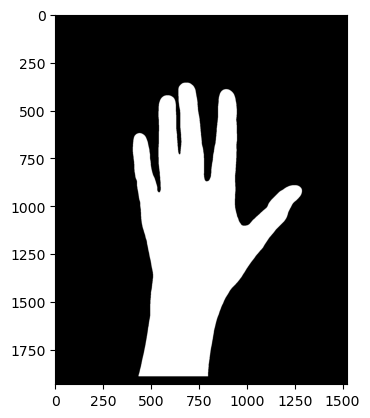

In [13]:
img  = np.asarray(Image.open(val_df["mask_path"].iloc[0]))
plt.imshow(img, cmap='gray')
w = np.count_nonzero(img)
t = img.shape[0] * img.shape[1]
w / t

### 1.3) Dataset

In [14]:
train_dataset = BAA_Dataset(train_df, transforms, apply_segmentation = apply_segmentation)
val_dataset = BAA_Dataset(val_df, transforms, apply_segmentation)

#### visualize

In [15]:
def denormalize(img):
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img

# to display normalized images with matplotlib - not necessary if images are processed in grayscale

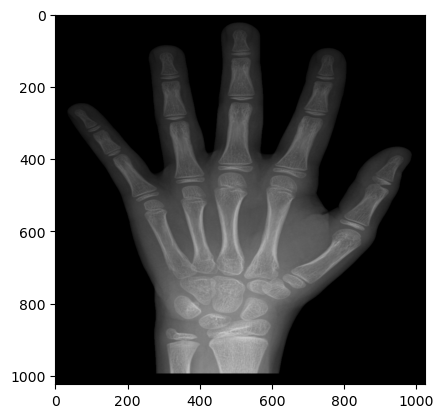

In [18]:
img, _, _ = val_dataset.__getitem__(4)
img = img.squeeze(0).cpu()
img = denormalize(img)
# if 3 color channels:
img = img.permute(1,2,0)
plt.imshow(img)

### 1.4) DataLoader

In [15]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)

## 2) Model

### 2.1) Initial Resnet18

In [3]:
# model = BAA_resnet18().to(device)
# model_type = 'resnet18'

In [16]:
model = BoneAgeEfficientNet(model_name = "tf_efficientnet_b4.ns_jft_in1k", hidden_dim = 1024).to(device)
model_type = 'efficientnet'

### 2.2) Loading a Checkpoint

In [17]:
checkpoint_path = path.join(getcwd(), "model", "checkpoints")
specific_checkpoint = "efficientnet_b4_1024x1024_aug_geo_best.pth"

In [18]:
p = path.join(checkpoint_path, specific_checkpoint)
if path.exists(p):
    checkpoint = torch.load(p, weights_only=False, map_location=torch.device('cpu'))
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    print("checkpoint doesn't exist")

## 3) Training

In [19]:
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
criterion = torch.nn.L1Loss()
n_epochs = 0

### 3.1) Training loop

In [15]:
train_losses = []
val_losses = []

In [45]:
# train_losses, val_losses = train_model(model, train_dataloader, val_dataloader, n_epochs, device, optimizer, criterion, checkpoint_path)

### 3.2) Eval only

In [1]:
mae = None
# mae = evaluate(model, val_dataloader, device, criterion)

In [2]:
print(mae)

None


### 3.3) Visualizing results

In [ ]:
if len(val_losses) > 0:
    print(train_losses[-1], val_losses[-1])

    mae = val_losses / val_dataset.shape[0]

    plt.figure()
    plt.plot(np.arange(len(train_losses)), train_losses)
    plt.plot(np.arange(len(val_losses)), val_losses)
    plt.legend(['train_loss', 'val_loss'])
    plt.xlabel('epoch')
    plt.ylabel('loss value (boneage months)')
    plt.title('{}: Train/val loss'.format("current model training results"));

### 3.4) Saving current model

In [ ]:
specific_checkpoint = f"checkpoint-{model_type}.pth"

In [ ]:
"""
p = path.join(checkpoint_path, specific_checkpoint)
state_dict = model.state_dict()

if mae is None:
    mae = evaluate(model, val_dataloader, device, criterion)

if path.exists(p):

    checkp = torch.load(p, weights_only=False)
    if checkp['mae'] < mae:
        print('new model sucks')
        state_dict = checkp['model_state_dict']



torch.save({
    'model_state_dict': model.state_dict(),
    'mae': mae
}, p)
"""

## 4) GRAD-Cam

In [73]:
output_dir = path.join(getcwd(), "output")

### 4.1) Set the target layer
You need to define the target layer: usually the last convolutional layer from whichever backbone model you chose.
For Restnet 18, it's divided into 4 "blocks" of layers, we want the last layer of the last block. I no longer specify it inside the model class !

In [233]:
target_layer = None
match model_type:
    case "resnet18":
        target_layer = model.backbone.layer4[-1]
    case "efficientnet":
        target_layer = model.backbone.conv_head
        target_layer = # model.backbone.blocks[-3] #ou -3
        

### 4.2) Generate Grad-CAM

In [234]:
grad_cam = GradCAM(model, target_layer)

### -- Apply it to a single input

In [235]:
img, gender, age, idx = val_dataset.get_random_items(1)[0]

In [236]:
u_img = img.unsqueeze(0).to(device)
u_gender = gender.unsqueeze(0).to(device)

print(f"img shape: {u_img.shape}, gender shape: {u_gender.shape}")

img shape: torch.Size([1, 3, 1024, 1024]), gender shape: torch.Size([1])


In [237]:
cam = grad_cam.generate(u_img, u_gender)
cam = cam.cpu()
resized_cam = grad_cam.resize_cam(cam, target_image_size)

In [238]:
pred = model(u_img, u_gender)

In [239]:
img = denormalize(img).squeeze(0).cpu()

# if 3 color channels:
img = img.permute(1, 2, 0)

single_rand_sample_cam_over_input_2.png


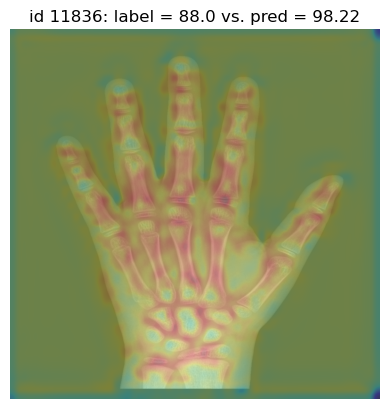

In [240]:
plt.imshow(img, cmap='gray', alpha=0.7)
plt.imshow(resized_cam, cmap='jet', alpha=0.3)
plt.axis('off')
plt.title(f"id {idx}: label = {age:.4} vs. pred = {pred.item():.4}")

p = path.join(output_dir, "single-rand_cam-over-input")
makedirs(p, exist_ok=True)

filename = f"single_rand_sample_cam_over_input_{len(listdir(p))}.png"
plt.savefig(path.join(p, filename), dpi=300, bbox_inches='tight')
print(filename)

### -- Apply it to multiple inputs

In [214]:
n = 9
nrows = 3
ncols = 3

In [215]:
rand_inputs = val_dataset.get_random_items(n)

8

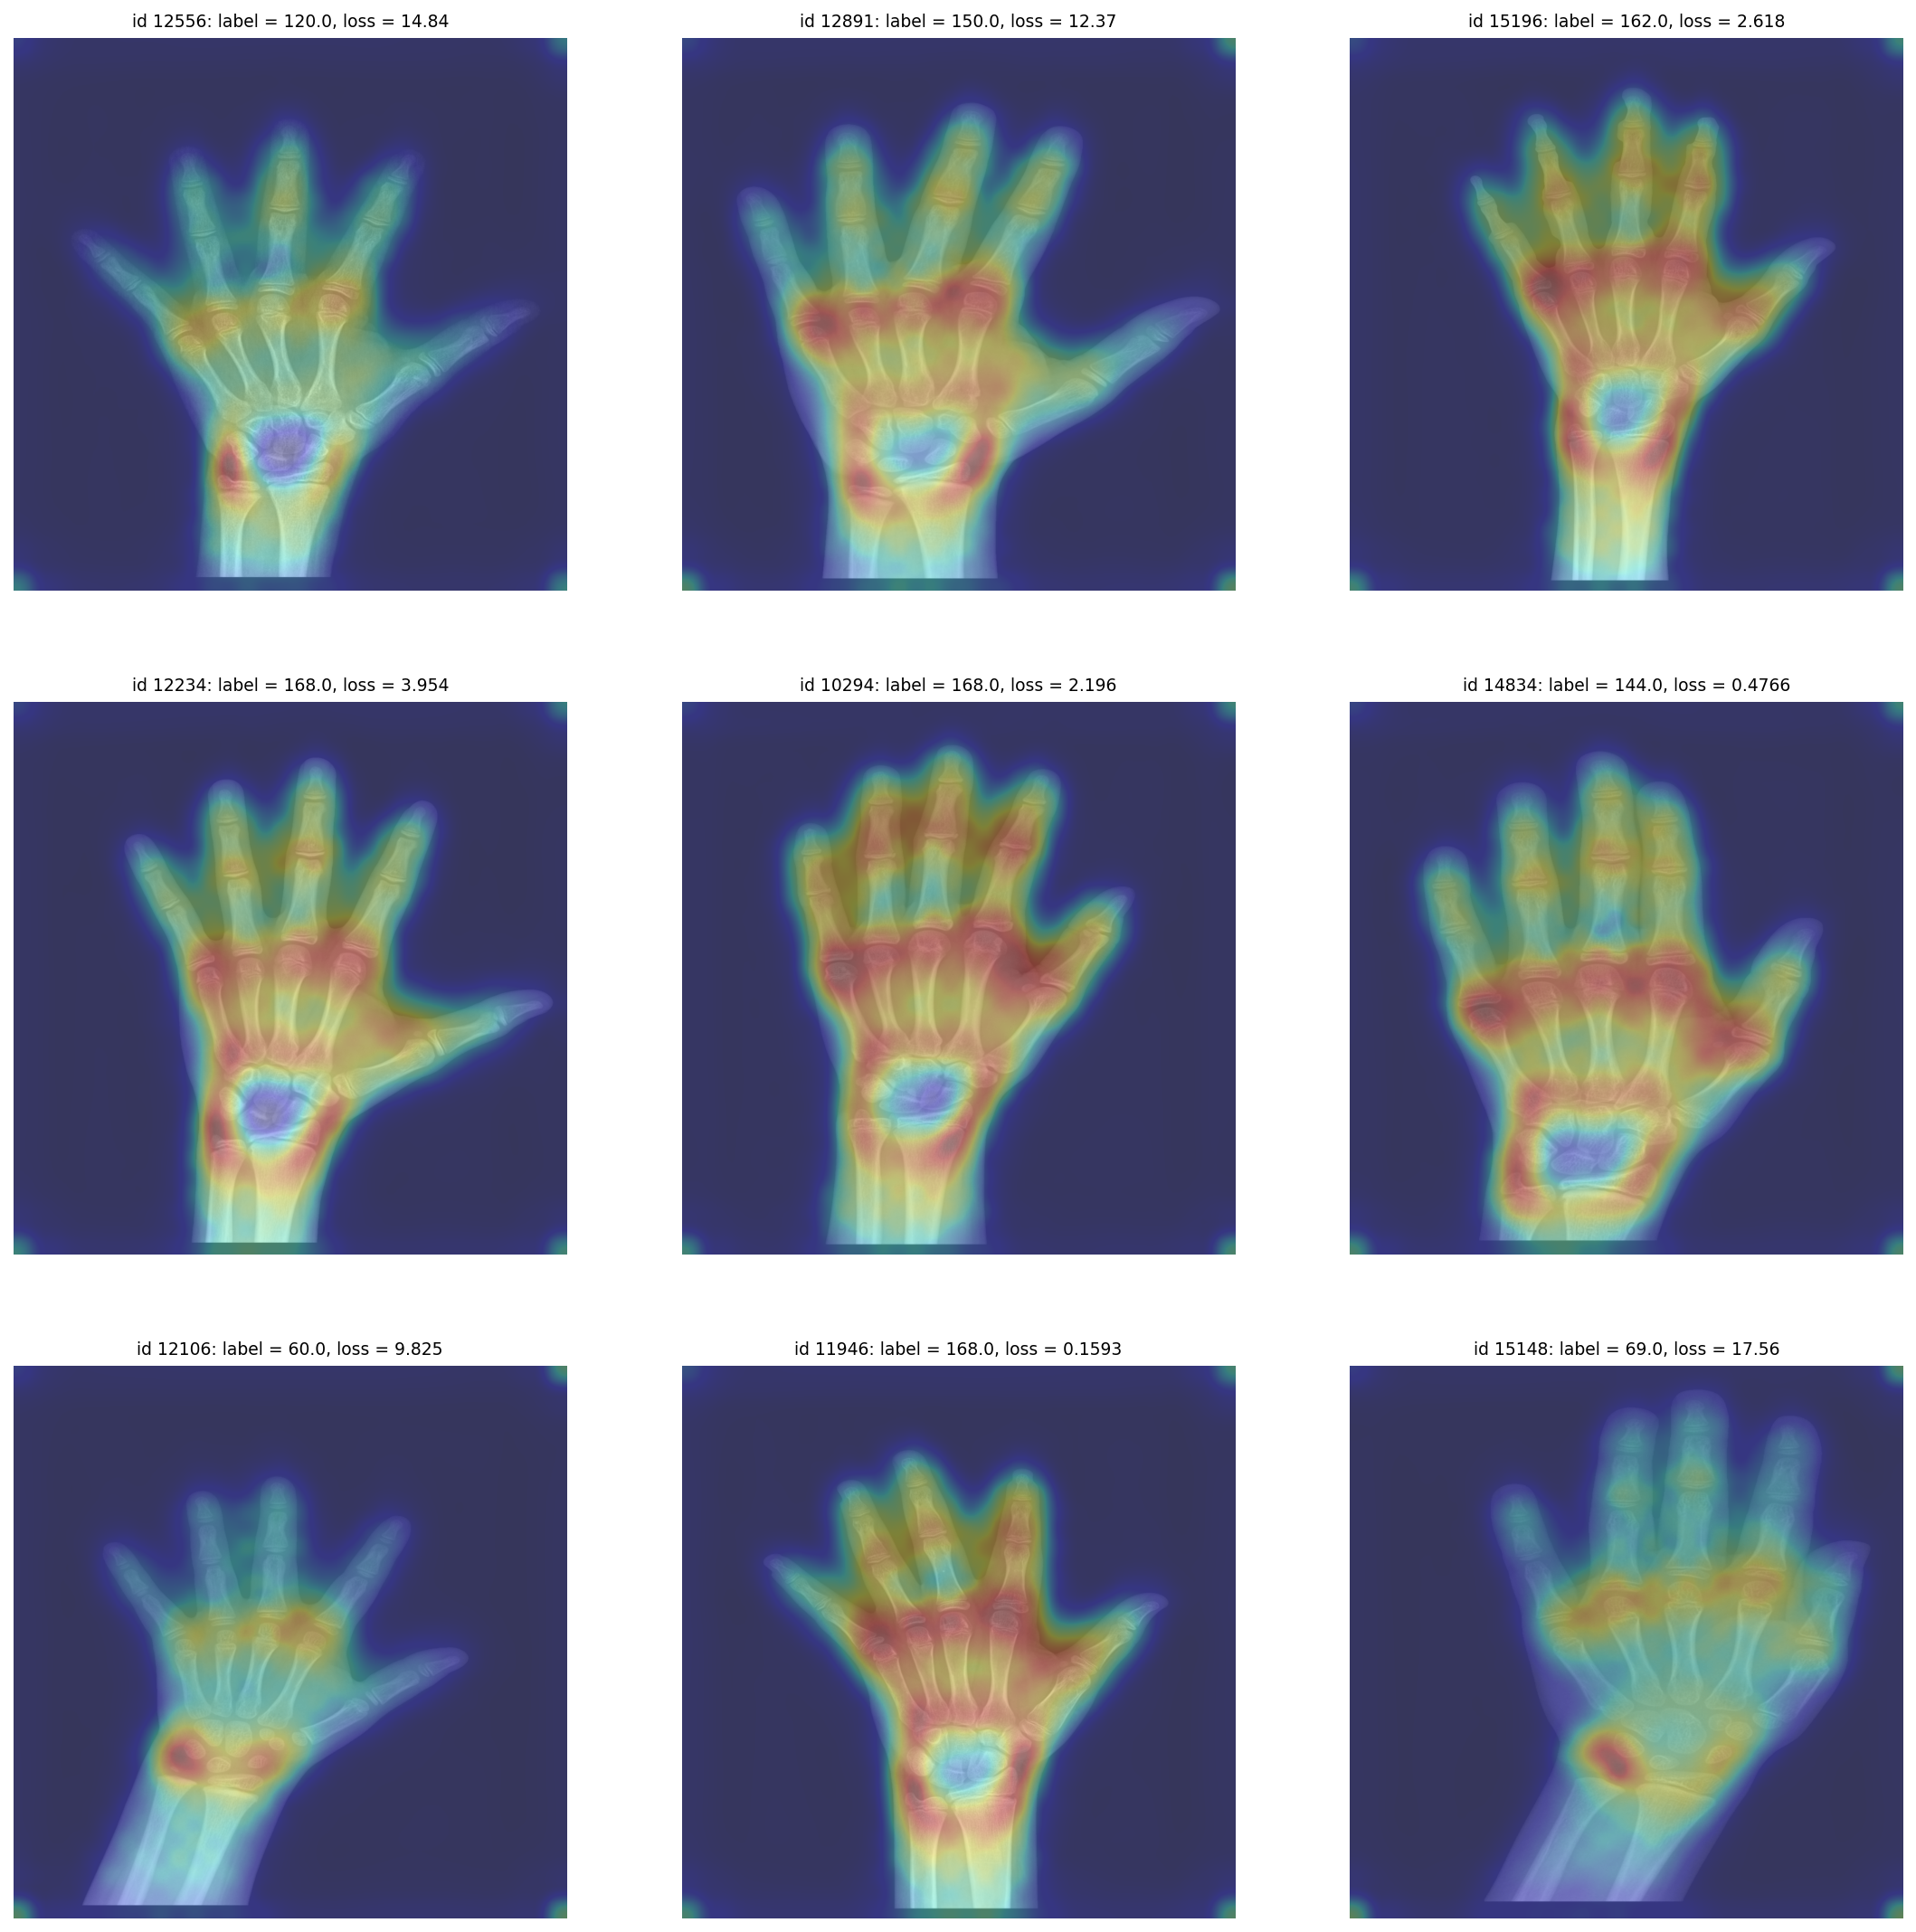

In [216]:
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 6 * nrows), dpi=150)

for i, test_input, sub_plot in zip(range(n), rand_inputs, fig.axes):

    print(f"{i}", end='\r')
    
    img, gender, age, idx = test_input
    u_img = img.unsqueeze(0).to(device)
    u_gender = gender.unsqueeze(0).to(device)

    cam = grad_cam.generate(u_img, u_gender)
    cam = cam.cpu()
    resized_cam = grad_cam.resize_cam(cam, target_image_size)

    pred = model(u_img, u_gender)

    img = denormalize(img).squeeze(0).cpu()
    

    # if 3 color channels:
    img = img.permute(1, 2, 0)

    sub_plot.imshow(img, cmap='gray', alpha=0.7)
    sub_plot.set_title(f"id {idx}: label = {age:.4}, loss = {criterion(age, pred.squeeze(0)):.4}", fontsize = 9)

    sub_plot.axis('off')
    sub_plot.imshow(resized_cam, cmap='jet', alpha=0.3)


p = path.join(output_dir, f"multiple_rand__cam_over_input")
makedirs(p, exist_ok=True)

filename = f"{n}_rand_samples_cam_over_input_{len(listdir(p))}.png"
plt.savefig(path.join(p, filename), dpi=300, bbox_inches='tight')

### -- compare CAM with and without resizing

In [211]:
nrows = 3

In [212]:
rand_inputs = val_dataset.get_random_items(nrows)

0-3_rand_samples_cam_vs_resized.png


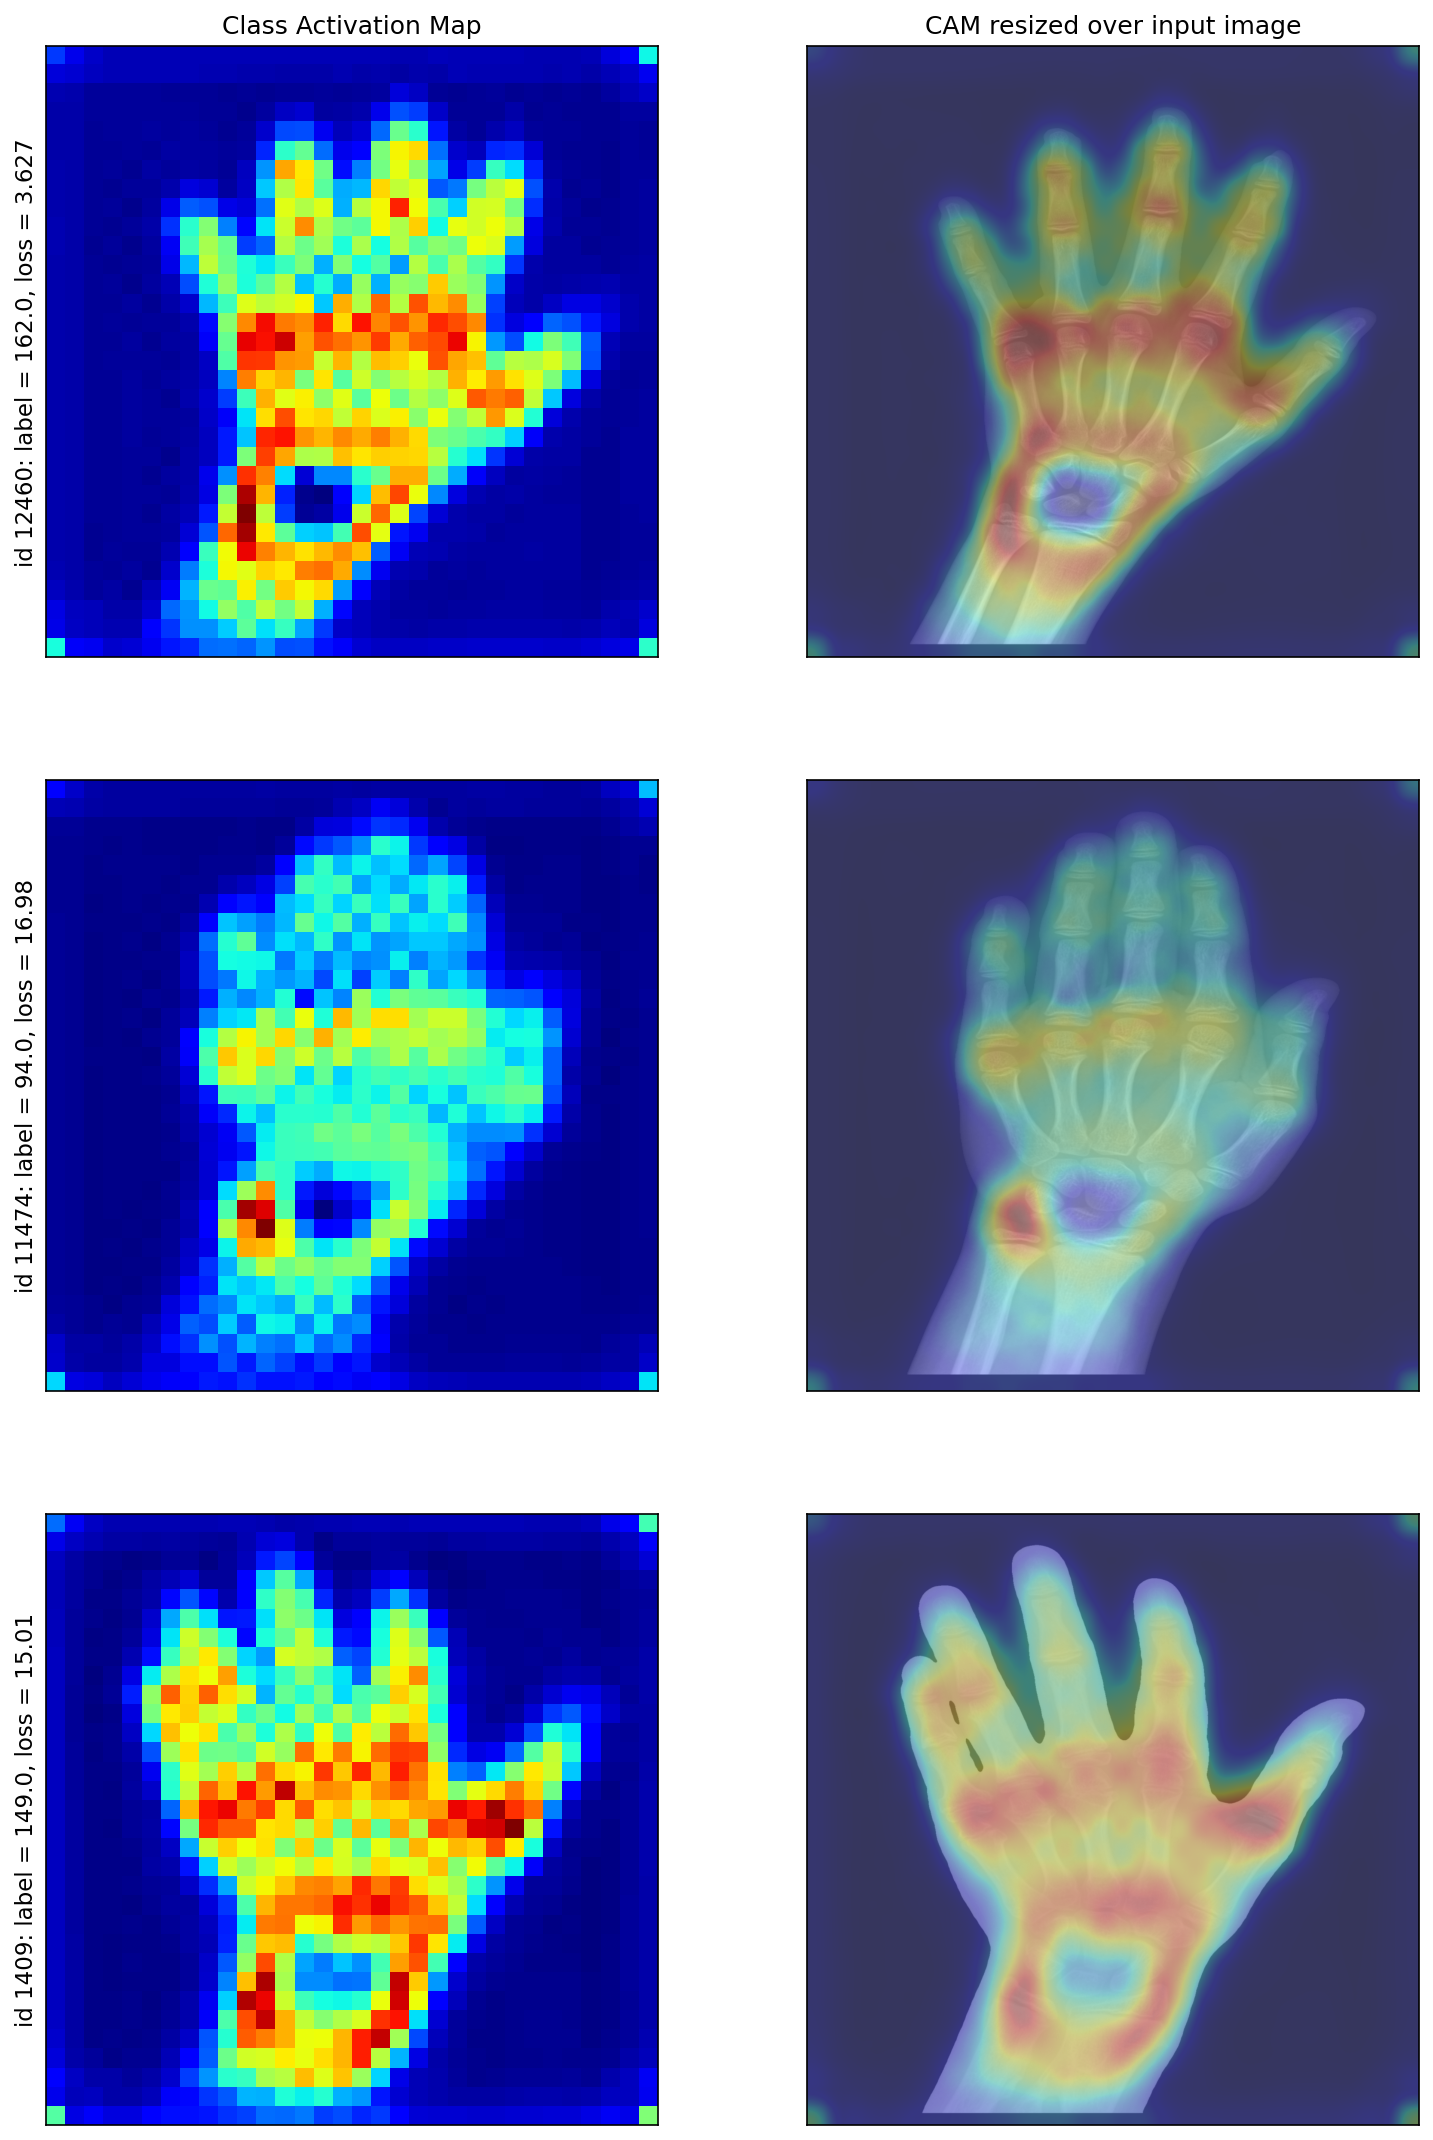

In [213]:
fig, ax = plt.subplots(nrows=nrows, ncols=2, figsize=(6 * 2, 6 * nrows), dpi=150)

for i in range (nrows):

    sub_plot.set_aspect('equal')
    
    img, gender, age, idx = rand_inputs[i]
    u_img = img.unsqueeze(0).to(device)
    u_gender = gender.unsqueeze(0).to(device)

    cam = grad_cam.generate(u_img, u_gender)
    cam = cam.cpu()
    resized_cam = grad_cam.resize_cam(cam, target_image_size)

    pred = model(u_img, u_gender)

    cam = cam.squeeze().detach().numpy()

    ax[i][0].imshow(cam, cmap='jet', alpha=1.0)
    ax[i][0].set_ylabel(f"id {idx}: label = {age:.4}, loss = {criterion(age, pred.squeeze(0)):.4}", fontsize = 11)
    ax[i][0].set_xticks([])
    ax[i][0].set_yticks([])

    img = denormalize(img).squeeze(0).cpu()
    
    # if 3 color channels:
    img = img.permute(1, 2, 0)
    
    ax[i][1].imshow(img, cmap='gray', alpha=0.7)
    ax[i][1].imshow(resized_cam, cmap='jet', alpha=0.3)
    ax[i][1].set_xticks([])
    ax[i][1].set_yticks([])

    if i == 0:
        ax[i][0].set_title("Class Activation Map")
        ax[i][1].set_title("CAM resized over input image")


    print(f"row {i}", end="\r")


p = path.join(output_dir, f"multiple_rand__cam_vs_resized")
makedirs(p, exist_ok=True)

filename = f"{nrows}_rand_samples_cam_vs_resized_{len(listdir(p))}.png"
plt.savefig(path.join(p, filename), dpi=300, bbox_inches='tight')
print(filename)